# Анализ падения конверсии сервиса МобиКар



## Описание кейса

**«МобиКар»** — сервис посуточной и почасовой аренды автомобилей через мобильное приложение. 

**Ключевые этапы онбординга нового пользователя**:
+ Установка приложения 
+ Регистрация 
+ Поиск автомобиля рядом 
+ Бронирование и начало поездки
   
**Проблема**: 
За последние 2 месяца зафиксировано снижение конверсии пользователей из первого входа в приложение до первой поездки на 15%

**Сопутствующие метрики и факты**: 
+ Количество установок выросло на 10%. 
+ Удержание зарегистрированных пользователей на 7-й день не изменилось. 
+ Крупных релизов не было, за исключением изменений в модуле поиска автомобилей.
+ Рейтинги и отзывы в магазинах приложений стабильны, негатива нет. 

#### **Подготовка нотбука**

In [116]:
#Импорт необходимых библиотек
import pandas as pd
import numpy as np 
from scipy.stats import norm 
import matplotlib.pyplot as plt
import seaborn as sns

#
plt.style.use('dark_background')
sns.set_theme(style="darkgrid")

#
plt.rcParams['font.family'] = 'DejaVu Sans' 
plt.rcParams['axes.unicode_minus'] = False

In [117]:
! gdown 15ejIPHshNCQIth6aSngqof91B16H_zKL

Downloading...
From: https://drive.google.com/uc?id=15ejIPHshNCQIth6aSngqof91B16H_zKL
To: /Users/gasikviktor2008/MobiCar_Case_data.xlsx
100%|██████████████████████████████████████| 12.2k/12.2k [00:00<00:00, 1.56MB/s]


## Загрузка данных  

#### **Ссылка на файл с данными**: 
https://docs.google.com/spreadsheets/d/15ejIPHshNCQIth6aSngqof91B16H_zKL/edit?usp=drive_link&ouid=112031436990814520139&rtpof=true&sd=true

**Информация о файле <span style="color: #E75480">MobiCar_Case_data</span>**:  
Файл содержит данные воронки сервиса МобиКар.
Одна строка - один день работы воронки.

#### **Структура таблицы**:

**Дата** - конкретный день, за который мы имеем данные.  
**Неделя** - неделя, к которой принадлежит дата наших наблюдений.  
**Установки** - число пользователей, установивших приложение Мобикар в конкретную дату наблюдений.   
**Рагистрации** - число пользователей, зарегистрировавшихся в сервисе Мобикар после установки приложения   
в конкретную дату наблюдений.  
**Открыли поиск** - число пользователей, открывших посик в приложении после установки и регистрации   
в конкретную дату наблюдений.  
**Просмотрели авто** - число пользователей, просмотревших авто после установки приложения, регистрации и 
использования меню поиска в конкретную дату наблюдений.  
**Забронировали** - число пользователей, забронировавших авто после установки приложения, регистрации, 
использования меню поиска и просмотра авто в конкретную дату наблюдений.  
**Первая поездка** - число пользователей,осуществивших поездку после установки приложения, регистрации, 
использования меню поиска, просмотра и брони автомобиля в конкретную дату наблюдений.




In [118]:
df_Mobi = pd.read_excel('/Users/gasikviktor2008/Downloads/MobiCar_Case_data.xlsx')
df_Mobi

,Дата,Неделя,Установки,Регистрации,Открыли поиск,Просмотрели авто,Забронировали,Первая поездка
0,06.01.2025,Неделя 1,206,130,91,70,57,51
1,07.01.2025,Неделя 1,216,138,98,73,55,48
2,08.01.2025,Неделя 1,181,117,86,69,52,46
3,09.01.2025,Неделя 1,212,134,101,83,64,54
4,10.01.2025,Неделя 1,218,143,97,73,60,53
5,11.01.2025,Неделя 1,212,146,106,90,70,62
6,12.01.2025,Неделя 1,213,145,110,89,72,60
7,13.01.2025,Неделя 2,189,123,83,64,48,41
8,14.01.2025,Неделя 2,205,135,95,73,56,52
9,15.01.2025,Неделя 2,206,140,96,79,59,51


# Подготовка данных к анализу

**Задачи на этом этапе**:
1) Удалить сводную строку с итогами, чтобы избежать возможных случайных искажений в дальнейших вычислениях.
2) Проверить таблицу на наличие пропусков, дубликатов и несоответсвий типов данных.

In [119]:
#Удаление итоговой строки
df_Mobi_2 = df_Mobi[df_Mobi['Дата'] != 'ИТОГО'].copy()
df_Mobi_2

,Дата,Неделя,Установки,Регистрации,Открыли поиск,Просмотрели авто,Забронировали,Первая поездка
0,06.01.2025,Неделя 1,206,130,91,70,57,51
1,07.01.2025,Неделя 1,216,138,98,73,55,48
2,08.01.2025,Неделя 1,181,117,86,69,52,46
3,09.01.2025,Неделя 1,212,134,101,83,64,54
4,10.01.2025,Неделя 1,218,143,97,73,60,53
5,11.01.2025,Неделя 1,212,146,106,90,70,62
6,12.01.2025,Неделя 1,213,145,110,89,72,60
7,13.01.2025,Неделя 2,189,123,83,64,48,41
8,14.01.2025,Неделя 2,205,135,95,73,56,52
9,15.01.2025,Неделя 2,206,140,96,79,59,51


In [120]:
#Проверка на наличие пропусков и несоответствий типов
df_Mobi_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 56 entries, 0 to 55
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Дата              56 non-null     object
 1   Неделя            56 non-null     object
 2   Установки         56 non-null     int64 
 3   Регистрации       56 non-null     int64 
 4   Открыли поиск     56 non-null     int64 
 5   Просмотрели авто  56 non-null     int64 
 6   Забронировали     56 non-null     int64 
 7   Первая поездка    56 non-null     int64 
dtypes: int64(6), object(2)
memory usage: 3.9+ KB


На основе полученной сводки видно, что все столбцы, содержащие числовые значения имеют тип int64, что свидетельствует  
о чистоте данных. Также видно, что ни один из столбцов не содержит null.

In [121]:
#Проверка на дубликаты по датам
is_dubl = df_Mobi_2['Дата'].nunique() == len(df_Mobi_2['Дата'])
is_dubl

True

Мы видим, что даты в таблице уникальны, дубликатов по датам нет.

# Декомпозиция задачи и агрегация данных

Учитывая, что удержание зарегистрированных пользователей на 7-й день не изменилось, можно сделать вывод, что причины падения итоговой конверсии нужно искать на начальных этапах воронки.  
Количество установок выросло на 10%, что свидетельствует о том, что одной из причин падения конверсии может быть привлчение в воронку некачественной аудитории.  
Крупных релизов не было, за исключением изменений в модуле поиска автомобилей, реакция пользователей на изменения в модуле поиска может  
также быть причиной изменений конверсии (сложный интерфейс, трудности с переходом в поиск).  
Рейтинги и отзывы в магазинах приложений стабильны, негатива нет, что свидетельствует об отсутствии изменений качества клиентского опыта 
Чтобы получить представление о воронке, я проанализировал датасет с посуточными данными за 8 недель.  
Данные были агрегированы до недельного уровня, чтобы минимизировать влияние ежедневного шума и случайных выбросов. 

**На этом шаге я посчитал**: 
1) Абсолютные количества пользователей на каждом этапе воронки. 
2) Конверсию между этапами 
3) Итоговую конверсию

### Агрегация данных и подсчет конверсии в разрезе недель

Данные в таблице, приложенной к кейсу, представлены без ID пользователей или любой другой информации, на основе которой можно было бы уйти в сторону когортного анализа удержания. 
Таблица предоставляет информацию об общем количестве пользователей по датам на всех этапах воронки. В ходе анализа я предполагаю, что все этапы воронки каждый из пользователей проходит в течение суток с момента регистрации. 

In [122]:
#Подсчёт абсолютного количества пользователей на каждом из этапов воронки
week_agregation = df_Mobi_2.groupby('Неделя')[['Установки', 'Регистрации', 'Открыли поиск', 'Просмотрели авто', 'Забронировали', 'Первая поездка']].sum()

#Рассчет конверсий между этапами в разрезе недель
week_agregation['CR_inst_reg'] = round(week_agregation['Регистрации'] / week_agregation['Установки'], 4)
week_agregation['CR_reg_search'] = round(week_agregation['Открыли поиск'] / week_agregation['Регистрации'], 4)
week_agregation['CR_search_find'] = round(week_agregation['Просмотрели авто'] / week_agregation['Открыли поиск'], 4)
week_agregation['CR_find_book'] = round(week_agregation['Забронировали'] / week_agregation['Просмотрели авто'], 4)
week_agregation['CR_book_ride'] = round(week_agregation['Первая поездка'] / week_agregation['Забронировали'], 4)

#Подсчёт итоговой конверсии
total_agregation = round(df_Mobi.loc[df_Mobi['Неделя'] == 'Нед. 1–8', 'Первая поездка'] / df_Mobi.loc[df_Mobi['Неделя'] == 'Нед. 1–8', 'Установки'], 4)

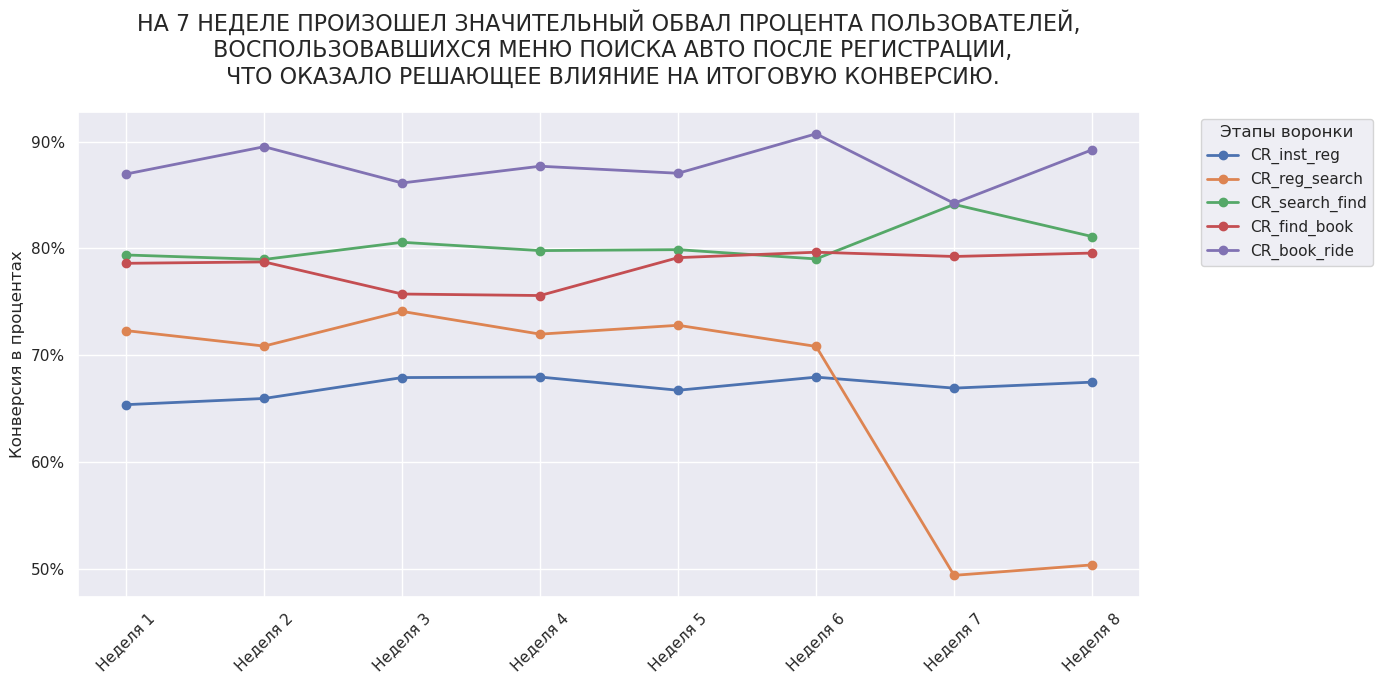

In [123]:
#Построение графика, визуализирующего динамику конверсий на всех этапах воронки

cr_columns = ['CR_inst_reg', 'CR_reg_search', 'CR_search_find', 'CR_find_book', 'CR_book_ride']

plt.figure(figsize=(14, 7))
for col in cr_columns:
    plt.plot(week_agregation.index, week_agregation[col], marker='o', linewidth=2, label=col)

plt.title('НА 7 НЕДЕЛЕ ПРОИЗОШЕЛ ЗНАЧИТЕЛЬНЫЙ ОБВАЛ ПРОЦЕНТА ПОЛЬЗОВАТЕЛЕЙ,\n ВОСПОЛЬЗОВАВШИХСЯ МЕНЮ ПОИСКА АВТО ПОСЛЕ РЕГИСТРАЦИИ,\n ЧТО ОКАЗАЛО РЕШАЮЩЕЕ ВЛИЯНИЕ НА ИТОГОВУЮ КОНВЕРСИЮ.', fontsize=16, pad=20)
plt.ylabel('Конверсия в процентах', fontsize=12)

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}')) # ось Y в процентах

plt.legend(title='Этапы воронки', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Интерпретация полученного результата:

**Из данных можно увидеть, что конверсия на большинстве этапов оставалась стабильной, что делает маловероятными версии с привлечением некачественного трафика. Однако на этапе перехода от регистрации к поиску авто заметно резкое падение**:   
Недели 1–6: Стабильная конверсия в районе 70,8%.   
Неделя 7-8: Резкое падение до 49,36% и последующее закрепление показателя на низком уровне 50,34%.  

## Проверка статистической значимости обнаруженного изменения конверсий

**Для подтверждения того, что выявленное падение на этапе перхода от регистрации к поиску не является случайным, была проведена статистическая проверка гипотез.**
**Гипотезы**: 
H0 : Конверсия не изменилась. 
H1 : Конверсия снизилась. 
Уровень значимости (α) = 0,05.
**Выборки**: 
Данные разделены на две независимые группы: 
1) Период до падения (недели 1–6). 
2) Период после падения (недели 7–8). 
(Я агрегировал данные по этапам “до предполагаемых изменений” и “после”)
   
**Критерий**: Z-тест для двух независимых пропорций (Потому что выборки независимы, объем данных  велик, целевые переменные дихотомические. 

In [124]:
#Суммируем пользователей, дошедших до этапа регистрации, и пользователей, перешедших в поиск авто, в период с 1 по 6 недели 
df_Mobi_3 = df_Mobi_2[(df_Mobi_2['Неделя'] != 'Неделя 7') & (df_Mobi_2['Неделя'] != 'Неделя 8')].copy()
reg_1_6 = df_Mobi_3['Регистрации'].sum()
find_1_6 = df_Mobi_3['Открыли поиск'].sum()	

#Суммируем пользователей, дошедших до этапа регистрации, и пользователей, перешедших в поиск авто, в период с 7 по 8 неделю
df_Mobi_4 = df_Mobi_2[(df_Mobi_2['Неделя'] == 'Неделя 7') | (df_Mobi_2['Неделя'] == 'Неделя 8')].copy()
reg_7_8 = df_Mobi_4['Регистрации'].sum()
find_7_8 = df_Mobi_4['Открыли поиск'].sum()

#Проверка стат значимости различий конверсий с помощью Z-теста для 2 пропорций
from statsmodels.stats.proportion import proportions_ztest 
successes = np.array([find_1_6, find_7_8]) 
n = np.array([reg_1_6, reg_7_8]) 
z_value, p_value = proportions_ztest(successes, n, alternative = 'larger') 
print(z_value, p_value) 

18.319694264427774 2.8817854142375794e-75


#### Результаты теста: 
Расчет p-value показал, что изменения конверсии на этапе перехода от регистрации к поиску является статистически значимыми (p_value < 0,05).  
Нулевая гипотеза отвергается.

## Рассчёт доверительного интервала

In [125]:
#Ввод переменных, которые необходимы для рассчете границ интервала
proportion_A =  find_1_6/reg_1_6
proportion_B =  find_7_8/reg_7_8
proportions_diff = proportion_B - proportion_A
#Вычисление стандартного отклонения разницы пропорций
se = np.sqrt(proportion_A * (1 - proportion_A) / reg_1_6 + proportion_B * (1 - proportion_B) / reg_7_8) 
alpha = 0.05 #Уровень надежности доверительного интервала 0.95
z_critical = norm.ppf(1 - alpha / 2) 

#Поиск границ доверительного интервала, покрывающего изменение конверсии для абсолютных и относительных значений
abs_dov_int_lower = round(proportions_diff - z_critical * se, 4) 
abs_dov_int_upper = round(proportions_diff + z_critical * se, 4) 
otn_dov_int_lower = (proportions_diff - z_critical * se) / proportion_A 
otn_dov_int_upper = (proportions_diff + z_critical * se) / proportion_A 
print(f"Разница конверсий: {proportions_diff * 100:.4f} в п.п.") 
print(f"95% Доверительный Интервал в абсолютных значениях: [{abs_dov_int_lower * 100:.4f}, {abs_dov_int_upper * 100:.4f}] в п.п.") 
print(f"95% Доверительный Интервал в относительных значениях: [{otn_dov_int_lower * 100:.4f}, {otn_dov_int_upper * 100:.4f}] в процентах") 

Разница конверсий: -22.3050 в п.п.
95% Доверительный Интервал в абсолютных значениях: [-24.7600, -19.8500] в п.п.
95% Доверительный Интервал в относительных значениях: [-34.3156, -27.5063] в процентах


**Рассчёт доверительного интервала показал, что итоговая конверсия из регистрации в поиск в период 6-7 недели, чем в период 7-8 недели.
При многократном повторении эксперимента в 95% случаев значение этого падения придётся на диапазон от 19.85 до 24.76 процентных пунктов.  
Если пересчитать это падение относительно исходной конверсии первой группы, то мы увидим интервал 27.51% – 34.32% падения от своего первоначального уровня**. 


## Выводы
В ходе анализа было установлено, что снижение общей конверсии из установки в первую поездку связано прежде всего с резким падением конверсии на этапе перехода от регистрации к открытию поиска. 

Остальные этапы воронки не демонстрируют сопоставимого ухудшения: конверсия из открытия поиска в просмотр автомобиля выросла с 79,63% до 82,60%, из просмотра в бронирование — с 77,87% до 79,41%, а из бронирования в первую поездку изменилась незначительно.

Таким образом, наиболее вероятная проблемная область - модуль поиска автомобилей, изменения в котором совпали с началом снижения конверсии. 

Для подтверждения гипотезы необходимо проверить корректность подсчета переходов в поиск после изменений, cовместить график изменений конверсии с графиком внедрения изменений в блоке поиска, рассмотреть долю пустых результатов, ошибки API, скорость загрузки, а также сравнить показатели по версиям приложения, операционным системам и регионам.

![График изменений конверсий, построенный в ](Diagrama_carshering.jpg)
